In [1]:
import copy
import json
import math
import os
import random
import warnings
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Dict, Optional, Tuple

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
from torch import Tensor, nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    # Reproducibility can slightly reduce performance.
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

In [2]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

PyTorch version: 2.13.0
Device: mps


# Config

In [3]:
@dataclass
class Config:
    data_path: Optional[str] = None

    # These values match the ATARNet notebook.
    control_segment: str = "No E-Mail"
    outcome_column: str = "visit"

    # Exact ATARNet held-out split.
    test_size: float = 0.20
    split_random_state: int = 42

    validation_size_within_train: float = 0.20
    validation_random_state: int = 42

    batch_size: int = 256
    max_epochs: int = 512
    patience: int = 20

    learning_rate: float = 1e-3
    weight_decay: float = 1e-4
    gradient_clip_norm: float = 5.0

    representation_dim: int = 16
    representation_hidden_dim: int = 32
    outcome_head_hidden_dim: int = 32
    dropout: float = 0.10

    propensity_loss_weight: float = 1.0
    targeted_regularization_weight: float = 0.10

    # Visits are less rare than conversions, but automatic class weighting
    # remains available. Set a numeric value to override it.
    positive_class_weight: Optional[float] = None

    output_dir: str = "dragonnet_outputs"
    seed: int = SEED

CONFIG = Config()

# Example manual overrides:
# CONFIG.data_path = "../data/raw/hillstrom_email.csv"
# CONFIG.atarnet_predictions_path = "../notebooks/atarnet_outputs/atarnet_test_predictions.csv"

print(json.dumps(asdict(CONFIG), indent=2))


{
  "data_path": null,
  "control_segment": "No E-Mail",
  "outcome_column": "visit",
  "test_size": 0.2,
  "split_random_state": 42,
  "validation_size_within_train": 0.2,
  "validation_random_state": 42,
  "batch_size": 256,
  "max_epochs": 150,
  "patience": 50,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "gradient_clip_norm": 5.0,
  "representation_dim": 16,
  "representation_hidden_dim": 32,
  "outcome_head_hidden_dim": 32,
  "dropout": 0.1,
  "propensity_loss_weight": 1.0,
  "targeted_regularization_weight": 0.1,
  "positive_class_weight": null,
  "output_dir": "dragonnet_outputs",
  "seed": 42
}


# Load dataset

In [4]:
DATA_PATH = "/Users/davinci/Projects/dragon_net/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv"
raw_df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH)
print("Raw shape:", raw_df.shape)
display(raw_df.head())

Loaded: /Users/davinci/Projects/dragon_net/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv
Raw shape: (64000, 12)


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


# Match ATARNet's treatment, outcome and feature defn

In [5]:
# Preserve the original row order and row index used by ATARNet.
analysis_df = raw_df.copy()
analysis_df["original_row_index"] = analysis_df.index.astype(int)

# Exact ATARNet treatment definition:
# both Womens E-Mail and Mens E-Mail are treated.
analysis_df["treatment"] = (
    analysis_df["segment"] != CONFIG.control_segment
).astype(np.float32)

analysis_df["outcome"] = analysis_df[
    CONFIG.outcome_column
].astype(np.float32)

# Exact ATARNet feature set.
numeric_columns = [
    "recency",
    "history",
    "mens",
    "womens",
]

categorical_columns = [
    "history_segment",
    "zip_code",
    "newbie",
    "channel",
]

feature_columns = numeric_columns + categorical_columns

X_raw = analysis_df[feature_columns].copy()
treatment = analysis_df["treatment"].to_numpy(dtype=np.float32)
outcome = analysis_df["outcome"].to_numpy(dtype=np.float32)

print("Analysis rows:", len(analysis_df))
print("Feature columns:", feature_columns)
print("\nTreatment counts:")
display(
    analysis_df["treatment"]
    .value_counts()
    .rename(index={0.0: "No E-Mail", 1.0: "Any E-Mail"})
    .to_frame("customers")
)

print("\nOutcome:", CONFIG.outcome_column)


Analysis rows: 64000
Feature columns: ['recency', 'history', 'mens', 'womens', 'history_segment', 'zip_code', 'newbie', 'channel']

Treatment counts:


,customers
treatment,
Any E-Mail,42694
No E-Mail,21306



Outcome: visit


## Reproduce ATARNet's held out test split

In [6]:
all_indices = np.arange(len(analysis_df))

# Exact ATARNet train/test split.
train_val_idx, test_idx = train_test_split(
    all_indices,
    test_size=CONFIG.test_size,
    random_state=CONFIG.split_random_state,
    stratify=treatment,
)

# DragonNet-only validation split from ATARNet's training portion.
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=CONFIG.validation_size_within_train,
    random_state=CONFIG.validation_random_state,
    stratify=treatment[train_val_idx],
)

X_train_raw = X_raw.iloc[train_idx].copy()
X_val_raw = X_raw.iloc[val_idx].copy()
X_test_raw = X_raw.iloc[test_idx].copy()

t_train = treatment[train_idx]
t_val = treatment[val_idx]
t_test = treatment[test_idx]

y_train = outcome[train_idx]
y_val = outcome[val_idx]
y_test = outcome[test_idx]

print("ATARNet original training portion:", len(train_val_idx))
print("DragonNet training rows:", len(train_idx))
print("DragonNet validation rows:", len(val_idx))
print("Shared held-out test rows:", len(test_idx))

print("\nShared test treatment counts:")
display(pd.Series(t_test).value_counts().sort_index().to_frame("rows"))

# Save split indices later so future models can reuse them exactly.
split_indices = {
    "atarnet_train_portion_indices": train_val_idx,
    "dragonnet_train_indices": train_idx,
    "dragonnet_validation_indices": val_idx,
    "shared_test_indices": test_idx,
}


ATARNet original training portion: 51200
DragonNet training rows: 40960
DragonNet validation rows: 10240
Shared held-out test rows: 12800

Shared test treatment counts:


,rows
0.0,4261
1.0,8539


# Preprocessing

In [7]:
try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False,
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False,
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_columns),
        ("categorical", one_hot_encoder, categorical_columns),
    ],
    remainder="drop",
)

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)
X_val = preprocessor.transform(X_val_raw).astype(np.float32)
X_test = preprocessor.transform(X_test_raw).astype(np.float32)

try:
    transformed_feature_names = preprocessor.get_feature_names_out().tolist()
except AttributeError:
    transformed_feature_names = [
        f"feature_{index}" for index in range(X_train.shape[1])
    ]

print("Categorical columns:", categorical_columns)
print("Numeric columns:", numeric_columns)
print("Transformed dimensions:", X_train.shape[1])
print("Train matrix:", X_train.shape)
print("Validation matrix:", X_val.shape)
print("Test matrix:", X_test.shape)


Categorical columns: ['history_segment', 'zip_code', 'newbie', 'channel']
Numeric columns: ['recency', 'history', 'mens', 'womens']
Transformed dimensions: 19
Train matrix: (40960, 19)
Validation matrix: (10240, 19)
Test matrix: (12800, 19)


# Build Datasets & Loaders

In [8]:
def make_tensor_dataset(
    X: np.ndarray,
    t: np.ndarray,
    y: np.ndarray,
) -> TensorDataset:
    return TensorDataset(
        torch.from_numpy(X).float(),
        torch.from_numpy(t).float().reshape(-1, 1),
        torch.from_numpy(y).float().reshape(-1, 1),
    )


train_dataset = make_tensor_dataset(X_train, t_train, y_train)
val_dataset = make_tensor_dataset(X_val, t_val, y_val)
test_dataset = make_tensor_dataset(X_test, t_test, y_test)

generator = torch.Generator()
generator.manual_seed(CONFIG.seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=True,
    generator=generator,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG.batch_size,
    shuffle=False,
)

print("Training batches:", len(train_loader))

Training batches: 160


# DragonNet architecture

The network has:

1. A shared representation \(Z=\phi(X)\)
2. A control-outcome head \(\hat{\mu}_0(X)\)
3. A treatment-outcome head \(\hat{\mu}_1(X)\)
4. A propensity head \(\hat{e}(X)=P(T=1\mid X)\)
5. A trainable scalar \(\epsilon\) for targeted regularization

The outcome heads predict the probability of a customer visit.


In [9]:
class DenseBlock(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        dropout: float = 0.0,
        use_batch_norm: bool = True,
    ):
        super().__init__()

        layers = [nn.Linear(input_dim, output_dim), nn.ELU()]

        if use_batch_norm:
            layers.append(nn.BatchNorm1d(output_dim))

        if dropout > 0:
            layers.append(nn.Dropout(dropout))

        self.block = nn.Sequential(*layers)

    def forward(self, x: Tensor) -> Tensor:
        return self.block(x)


class OutcomeHead(nn.Module):
    def __init__(
        self,
        representation_dim: int,
        hidden_dim: int,
        dropout: float,
    ):
        super().__init__()

        self.network = nn.Sequential(
            DenseBlock(
                representation_dim,
                hidden_dim,
                dropout=dropout,
            ),
            DenseBlock(
                hidden_dim,
                hidden_dim,
                dropout=dropout,
            ),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, representation: Tensor) -> Tensor:
        return self.network(representation)


class DragonNet(nn.Module):
    def __init__(
        self,
        input_dim: int,
        representation_hidden_dim: int = 128,
        representation_dim: int = 64,
        outcome_head_hidden_dim: int = 32,
        dropout: float = 0.10,
    ):
        super().__init__()

        self.representation = nn.Sequential(
            DenseBlock(
                input_dim,
                representation_hidden_dim,
                dropout=dropout,
            ),
            DenseBlock(
                representation_hidden_dim,
                representation_hidden_dim,
                dropout=dropout,
            ),
            DenseBlock(
                representation_hidden_dim,
                representation_dim,
                dropout=dropout,
            ),
        )

        self.control_outcome_head = OutcomeHead(
            representation_dim=representation_dim,
            hidden_dim=outcome_head_hidden_dim,
            dropout=dropout,
        )

        self.treatment_outcome_head = OutcomeHead(
            representation_dim=representation_dim,
            hidden_dim=outcome_head_hidden_dim,
            dropout=dropout,
        )

        self.propensity_head = nn.Linear(representation_dim, 1)

        # Targeted-regularization fluctuation parameter.
        self.epsilon = nn.Parameter(torch.zeros(1))

    def forward(self, x: Tensor) -> Dict[str, Tensor]:
        representation = self.representation(x)

        return {
            "control_logit": self.control_outcome_head(representation),
            "treatment_logit": self.treatment_outcome_head(representation),
            "propensity_logit": self.propensity_head(representation),
            "epsilon": self.epsilon,
            "representation": representation,
        }


model = DragonNet(
    input_dim=X_train.shape[1],
    representation_hidden_dim=CONFIG.representation_hidden_dim,
    representation_dim=CONFIG.representation_dim,
    outcome_head_hidden_dim=CONFIG.outcome_head_hidden_dim,
    dropout=CONFIG.dropout,
).to(DEVICE)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(model)
print(f"\nTrainable parameters: {trainable_parameters:,}")

DragonNet(
  (representation): Sequential(
    (0): DenseBlock(
      (block): Sequential(
        (0): Linear(in_features=19, out_features=32, bias=True)
        (1): ELU(alpha=1.0)
        (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
    (1): DenseBlock(
      (block): Sequential(
        (0): Linear(in_features=32, out_features=32, bias=True)
        (1): ELU(alpha=1.0)
        (2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
    (2): DenseBlock(
      (block): Sequential(
        (0): Linear(in_features=32, out_features=16, bias=True)
        (1): ELU(alpha=1.0)
        (2): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
        (3): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (control_outcome_head): OutcomeHead(
    (networ

# Loss Functions

In [10]:
def calculate_positive_class_weight(y: np.ndarray) -> float:
    positives = float(np.sum(y == 1))
    negatives = float(np.sum(y == 0))

    if positives == 0:
        raise ValueError("Training outcome has no positive observations.")

    return negatives / positives


if CONFIG.positive_class_weight is None:
    POSITIVE_CLASS_WEIGHT = calculate_positive_class_weight(y_train)
else:
    POSITIVE_CLASS_WEIGHT = float(CONFIG.positive_class_weight)

print(f"Positive-class weight: {POSITIVE_CLASS_WEIGHT:.3f}")


def dragonnet_loss(
    outputs: Dict[str, Tensor],
    treatment: Tensor,
    outcome: Tensor,
    propensity_loss_weight: float,
    targeted_regularization_weight: float,
    positive_class_weight: float,
    propensity_clip: float = 1e-3,
) -> Dict[str, Tensor]:
    control_logit = outputs["control_logit"]
    treatment_logit = outputs["treatment_logit"]
    propensity_logit = outputs["propensity_logit"]

    factual_logit = (
        treatment * treatment_logit
        + (1.0 - treatment) * control_logit
    )

    pos_weight_tensor = torch.tensor(
        [positive_class_weight],
        dtype=factual_logit.dtype,
        device=factual_logit.device,
    )

    outcome_loss = nn.functional.binary_cross_entropy_with_logits(
        factual_logit,
        outcome,
        pos_weight=pos_weight_tensor,
    )

    propensity_loss = nn.functional.binary_cross_entropy_with_logits(
        propensity_logit,
        treatment,
    )

    propensity = torch.sigmoid(propensity_logit).clamp(
        propensity_clip,
        1.0 - propensity_clip,
    )

    factual_probability = torch.sigmoid(factual_logit).clamp(
        propensity_clip,
        1.0 - propensity_clip,
    )

    clever_covariate = (
        treatment / propensity
        - (1.0 - treatment) / (1.0 - propensity)
    )

    targeted_logit = (
        torch.logit(factual_probability)
        + outputs["epsilon"] * clever_covariate
    )

    targeted_loss = nn.functional.binary_cross_entropy_with_logits(
        targeted_logit,
        outcome,
        pos_weight=pos_weight_tensor,
    )

    total_loss = (
        outcome_loss
        + propensity_loss_weight * propensity_loss
        + targeted_regularization_weight * targeted_loss
    )

    return {
        "total": total_loss,
        "outcome": outcome_loss,
        "propensity": propensity_loss,
        "targeted": targeted_loss,
        "factual_logit": factual_logit,
    }

Positive-class weight: 5.897


# Training & Validation

In [11]:
@dataclass
class EpochMetrics:
    total_loss: float
    outcome_loss: float
    propensity_loss: float
    targeted_loss: float


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: Optional[torch.optim.Optimizer] = None,
) -> EpochMetrics:
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    totals = {
        "total": 0.0,
        "outcome": 0.0,
        "propensity": 0.0,
        "targeted": 0.0,
    }

    observations = 0

    for X_batch, t_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        t_batch = t_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            outputs = model(X_batch)

            losses = dragonnet_loss(
                outputs=outputs,
                treatment=t_batch,
                outcome=y_batch,
                propensity_loss_weight=CONFIG.propensity_loss_weight,
                targeted_regularization_weight=(
                    CONFIG.targeted_regularization_weight
                ),
                positive_class_weight=POSITIVE_CLASS_WEIGHT,
            )

            if is_training:
                losses["total"].backward()

                nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=CONFIG.gradient_clip_norm,
                )

                optimizer.step()

        batch_size = len(X_batch)
        observations += batch_size

        for key in totals:
            totals[key] += losses[key].detach().item() * batch_size

    return EpochMetrics(
        total_loss=totals["total"] / observations,
        outcome_loss=totals["outcome"] / observations,
        propensity_loss=totals["propensity"] / observations,
        targeted_loss=totals["targeted"] / observations,
    )


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
) -> pd.DataFrame:
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=CONFIG.learning_rate,
        weight_decay=CONFIG.weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
    )

    best_state = None
    best_validation_loss = math.inf
    epochs_without_improvement = 0
    history_records = []

    for epoch in range(1, CONFIG.max_epochs + 1):
        train_metrics = run_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
        )

        validation_metrics = run_epoch(
            model=model,
            loader=val_loader,
            optimizer=None,
        )

        scheduler.step(validation_metrics.total_loss)

        learning_rate = optimizer.param_groups[0]["lr"]

        history_records.append({
            "epoch": epoch,
            "learning_rate": learning_rate,
            "train_total_loss": train_metrics.total_loss,
            "train_outcome_loss": train_metrics.outcome_loss,
            "train_propensity_loss": train_metrics.propensity_loss,
            "train_targeted_loss": train_metrics.targeted_loss,
            "validation_total_loss": validation_metrics.total_loss,
            "validation_outcome_loss": validation_metrics.outcome_loss,
            "validation_propensity_loss": validation_metrics.propensity_loss,
            "validation_targeted_loss": validation_metrics.targeted_loss,
        })

        improved = (
            validation_metrics.total_loss
            < best_validation_loss - 1e-5
        )

        if improved:
            best_validation_loss = validation_metrics.total_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epoch == 1 or epoch % 10 == 0 or improved:
            print(
                f"Epoch {epoch:03d} | "
                f"train={train_metrics.total_loss:.5f} | "
                f"val={validation_metrics.total_loss:.5f} | "
                f"lr={learning_rate:.2e}"
            )

        if epochs_without_improvement >= CONFIG.patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    if best_state is None:
        raise RuntimeError("No valid model checkpoint was created.")

    model.load_state_dict(best_state)

    print(
        "Restored best checkpoint with validation loss "
        f"{best_validation_loss:.5f}."
    )

    return pd.DataFrame(history_records)


In [12]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
)

display(history.tail())

Epoch 001 | train=1.96510 | val=1.92515 | lr=1.00e-03
Epoch 002 | train=1.90854 | val=1.90342 | lr=1.00e-03
Epoch 004 | train=1.88926 | val=1.90121 | lr=1.00e-03
Epoch 006 | train=1.88559 | val=1.89734 | lr=1.00e-03
Epoch 010 | train=1.88113 | val=1.89977 | lr=1.00e-03
Epoch 011 | train=1.88207 | val=1.89683 | lr=1.00e-03
Epoch 020 | train=1.87429 | val=1.89843 | lr=5.00e-04
Epoch 030 | train=1.87258 | val=1.89895 | lr=1.25e-04
Epoch 040 | train=1.87386 | val=1.89854 | lr=6.25e-05
Epoch 050 | train=1.87359 | val=1.89870 | lr=1.56e-05
Epoch 060 | train=1.87341 | val=1.89823 | lr=3.91e-06
Early stopping at epoch 61.
Restored best checkpoint with validation loss 1.89683.


,epoch,learning_rate,train_total_loss,train_outcome_loss,train_propensity_loss,train_targeted_loss,validation_total_loss,validation_outcome_loss,validation_propensity_loss,validation_targeted_loss
56,57,0.000008,1.870338,1.121757,0.636406,1.121757,1.898068,1.147145,0.636209,1.147139
57,58,0.000008,1.872323,1.123368,0.636618,1.123368,1.898207,1.147286,0.636194,1.147280
58,59,0.000004,1.872484,1.123864,0.636233,1.123865,1.898325,1.147382,0.636206,1.147377
59,60,0.000004,1.873414,1.124580,0.636376,1.124580,1.898233,1.147305,0.636198,1.147299
60,61,0.000004,1.871243,1.122579,0.636407,1.122579,1.898254,1.147316,0.636207,1.147311


# Plots & Evaluation

## Plot & Evaluate training history

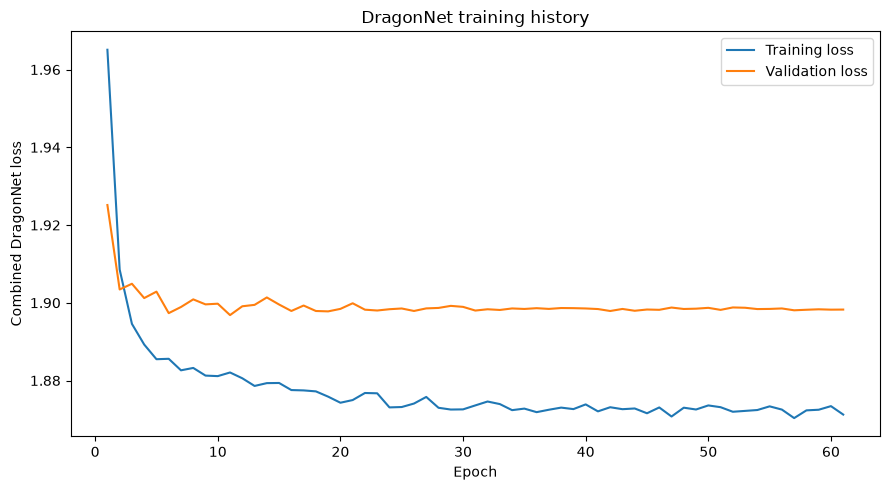

In [13]:
plt.figure(figsize=(9, 5))
plt.plot(
    history["epoch"],
    history["train_total_loss"],
    label="Training loss",
)
plt.plot(
    history["epoch"],
    history["validation_total_loss"],
    label="Validation loss",
)
plt.xlabel("Epoch")
plt.ylabel("Combined DragonNet loss")
plt.title("DragonNet training history")
plt.legend()
plt.tight_layout()
plt.show()


## Predict outcomes & uplift

In [14]:
@torch.no_grad()
def predict_potential_outcomes(
    model: nn.Module,
    X: np.ndarray,
    batch_size: int = 2048,
) -> Dict[str, np.ndarray]:
    model.eval()

    dataset = TensorDataset(torch.from_numpy(X).float())
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
    )

    control_probabilities = []
    treatment_probabilities = []
    propensity_probabilities = []

    for (X_batch,) in loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)

        control_probabilities.append(
            torch.sigmoid(outputs["control_logit"])
            .cpu()
            .numpy()
        )

        treatment_probabilities.append(
            torch.sigmoid(outputs["treatment_logit"])
            .cpu()
            .numpy()
        )

        propensity_probabilities.append(
            torch.sigmoid(outputs["propensity_logit"])
            .cpu()
            .numpy()
        )

    mu0 = np.concatenate(control_probabilities).reshape(-1)
    mu1 = np.concatenate(treatment_probabilities).reshape(-1)
    propensity = np.concatenate(
        propensity_probabilities
    ).reshape(-1)

    return {
        "mu0": mu0,
        "mu1": mu1,
        "propensity": propensity,
        "uplift": mu1 - mu0,
    }


test_predictions = predict_potential_outcomes(
    model=model,
    X=X_test,
)

test_results = analysis_df.iloc[test_idx].copy().reset_index(drop=True)

test_results["actual_treatment"] = t_test.astype(int)
test_results["actual_outcome"] = y_test.astype(int)
test_results["predicted_mu0"] = test_predictions["mu0"]
test_results["predicted_mu1"] = test_predictions["mu1"]
test_results["predicted_propensity"] = test_predictions["propensity"]
test_results["predicted_uplift"] = test_predictions["uplift"]

display(
    test_results[
        [
            "actual_treatment",
            "actual_outcome",
            "predicted_mu0",
            "predicted_mu1",
            "predicted_propensity",
            "predicted_uplift",
        ]
    ].head()
)

display(
    test_results["predicted_uplift"]
    .describe()
    .to_frame("predicted_uplift")
)


,actual_treatment,actual_outcome,predicted_mu0,predicted_mu1,predicted_propensity,predicted_uplift
0,1,1,0.367550,0.573468,0.662940,0.205918
1,1,0,0.523369,0.667227,0.682389,0.143857
2,1,0,0.355231,0.445619,0.645077,0.090388
3,1,0,0.347347,0.455887,0.653990,0.108541
4,1,0,0.259551,0.479021,0.649841,0.219470


,predicted_uplift
count,12800.000000
mean,0.134266
std,0.057065
min,-0.010024
25%,0.087965
50%,0.129565
75%,0.170025
max,0.310904


## Qini Curve in comparison to random targeting

In [15]:
arm_summary = (
    analysis_df.groupby("treatment")
    .agg(
        customers=("outcome", "size"),
        visit_rate=("outcome", "mean"),
        conversion_rate=("conversion", "mean"),
        average_spend=("spend", "mean"),
    )
    .rename(index={0.0: "No E-Mail", 1.0: "Any E-Mail"})
)

display(arm_summary)

control_outcome_rate = analysis_df.loc[
    analysis_df["treatment"] == 0, "outcome"
].mean()

treatment_outcome_rate = analysis_df.loc[
    analysis_df["treatment"] == 1, "outcome"
].mean()

naive_ate = treatment_outcome_rate - control_outcome_rate

print(f"Observed control visit rate:   {control_outcome_rate:.6f}")
print(f"Observed treatment visit rate: {treatment_outcome_rate:.6f}")
print(f"Difference in means / raw ATE: {naive_ate:.6f}")

,customers,visit_rate,conversion_rate,average_spend
treatment,,,,
No E-Mail,21306,0.106167,0.005726,0.652789
Any E-Mail,42694,0.167049,0.010681,1.249585


Observed control visit rate:   0.106167
Observed treatment visit rate: 0.167049
Difference in means / raw ATE: 0.060882


Qini coefficient: 25.063032


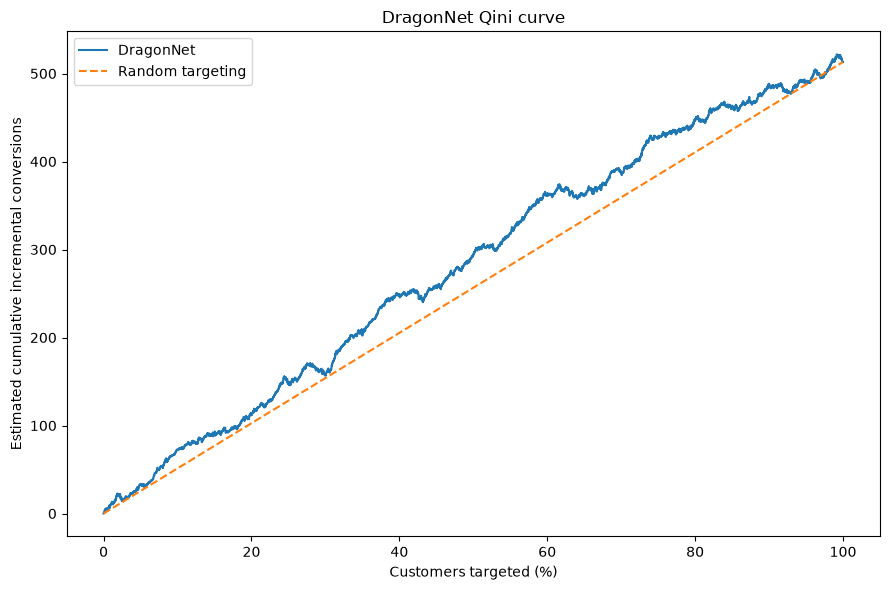

In [16]:
def qini_curve(
    treatment: np.ndarray,
    outcome: np.ndarray,
    uplift: np.ndarray,
) -> pd.DataFrame:
    ranked = pd.DataFrame({
        "treatment": np.asarray(treatment).astype(float),
        "outcome": np.asarray(outcome).astype(float),
        "uplift": np.asarray(uplift).astype(float),
    })

    ranked = (
        ranked.sort_values(
            "uplift",
            ascending=False,
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    ranked["treated_outcome"] = (
        ranked["treatment"] * ranked["outcome"]
    )

    ranked["control_outcome"] = (
        (1.0 - ranked["treatment"]) * ranked["outcome"]
    )

    cumulative_treated_outcome = ranked[
        "treated_outcome"
    ].cumsum()

    cumulative_control_outcome = ranked[
        "control_outcome"
    ].cumsum()

    cumulative_treated_count = ranked[
        "treatment"
    ].cumsum()

    cumulative_control_count = (
        1.0 - ranked["treatment"]
    ).cumsum()

    scaled_control_outcome = (
        cumulative_control_outcome
        * cumulative_treated_count
        / cumulative_control_count.replace(0, np.nan)
    )

    incremental_gain = (
        cumulative_treated_outcome - scaled_control_outcome
    ).fillna(0.0)

    curve = pd.DataFrame({
        "fraction_targeted": (
            np.arange(1, len(ranked) + 1) / len(ranked)
        ),
        "incremental_gain": incremental_gain,
    })

    origin = pd.DataFrame({
        "fraction_targeted": [0.0],
        "incremental_gain": [0.0],
    })

    return pd.concat(
        [origin, curve],
        ignore_index=True,
    )


def qini_coefficient(curve: pd.DataFrame) -> float:
    x = curve["fraction_targeted"].to_numpy()
    gain = curve["incremental_gain"].to_numpy()

    random_gain = x * gain[-1]

    return float(
        np.trapezoid(gain - random_gain, x)
    )


dragonnet_qini = qini_curve(
    treatment=t_test,
    outcome=y_test,
    uplift=test_results["predicted_uplift"].to_numpy(),
)

dragonnet_qini_score = qini_coefficient(dragonnet_qini)

print(f"Qini coefficient: {dragonnet_qini_score:.6f}")

plt.figure(figsize=(9, 6))

plt.plot(
    dragonnet_qini["fraction_targeted"] * 100,
    dragonnet_qini["incremental_gain"],
    label="DragonNet",
)

plt.plot(
    dragonnet_qini["fraction_targeted"] * 100,
    dragonnet_qini["fraction_targeted"]
    * dragonnet_qini["incremental_gain"].iloc[-1],
    linestyle="--",
    label="Random targeting",
)

plt.xlabel("Customers targeted (%)")
plt.ylabel("Estimated cumulative incremental conversions")
plt.title("DragonNet Qini curve")
plt.legend()
plt.tight_layout()
plt.show()


## Uplift Curve & AUUC

AUUC: 0.068889


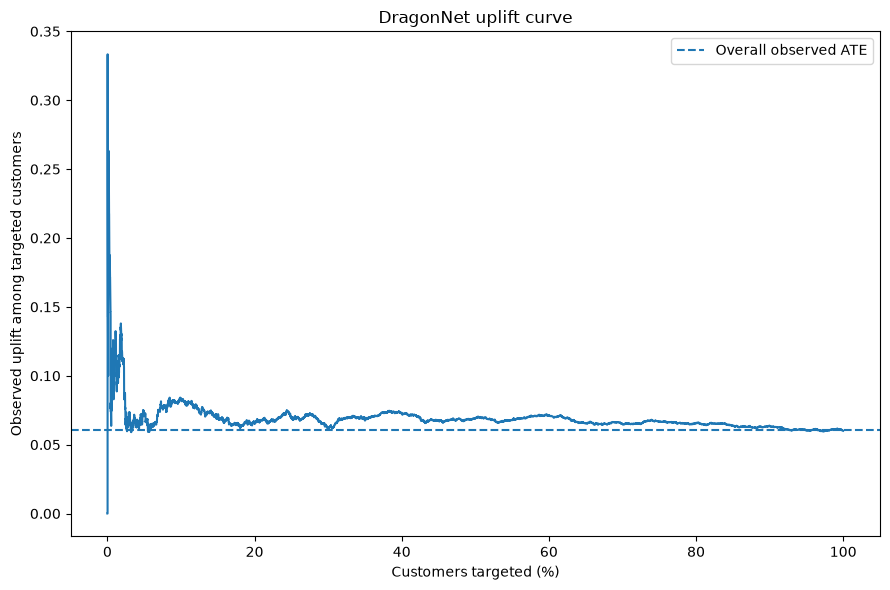

In [17]:
def uplift_curve(
    treatment: np.ndarray,
    outcome: np.ndarray,
    uplift: np.ndarray,
) -> pd.DataFrame:
    ranked = pd.DataFrame({
        "treatment": np.asarray(treatment).astype(float),
        "outcome": np.asarray(outcome).astype(float),
        "uplift": np.asarray(uplift).astype(float),
    })

    ranked = (
        ranked.sort_values(
            "uplift",
            ascending=False,
            kind="mergesort",
        )
        .reset_index(drop=True)
    )

    treated_outcome_cumulative = (
        ranked["outcome"] * ranked["treatment"]
    ).cumsum()

    control_outcome_cumulative = (
        ranked["outcome"] * (1.0 - ranked["treatment"])
    ).cumsum()

    treated_count_cumulative = ranked["treatment"].cumsum()
    control_count_cumulative = (
        1.0 - ranked["treatment"]
    ).cumsum()

    treated_rate = (
        treated_outcome_cumulative
        / treated_count_cumulative.replace(0, np.nan)
    )

    control_rate = (
        control_outcome_cumulative
        / control_count_cumulative.replace(0, np.nan)
    )

    uplift_at_depth = (
        treated_rate - control_rate
    ).fillna(0.0)

    curve = pd.DataFrame({
        "fraction_targeted": (
            np.arange(1, len(ranked) + 1) / len(ranked)
        ),
        "uplift_at_depth": uplift_at_depth,
    })

    origin = pd.DataFrame({
        "fraction_targeted": [0.0],
        "uplift_at_depth": [0.0],
    })

    return pd.concat(
        [origin, curve],
        ignore_index=True,
    )


def area_under_uplift_curve(curve: pd.DataFrame) -> float:
    return float(
        np.trapezoid(
            curve["uplift_at_depth"],
            curve["fraction_targeted"],
        )
    )


dragonnet_uplift_curve = uplift_curve(
    treatment=t_test,
    outcome=y_test,
    uplift=test_results["predicted_uplift"].to_numpy(),
)

auuc = area_under_uplift_curve(
    dragonnet_uplift_curve
)

print(f"AUUC: {auuc:.6f}")

plt.figure(figsize=(9, 6))
plt.plot(
    dragonnet_uplift_curve["fraction_targeted"] * 100,
    dragonnet_uplift_curve["uplift_at_depth"],
)
plt.axhline(
    y=naive_ate,
    linestyle="--",
    label="Overall observed ATE",
)
plt.xlabel("Customers targeted (%)")
plt.ylabel("Observed uplift among targeted customers")
plt.title("DragonNet uplift curve")
plt.legend()
plt.tight_layout()
plt.show()

# Aux Metrics

In [18]:
factual_probability = np.where(
    t_test == 1,
    test_results["predicted_mu1"],
    test_results["predicted_mu0"],
)

def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)

auxiliary_metrics = pd.Series({
    "factual_log_loss": log_loss(
        y_test,
        np.clip(factual_probability, 1e-6, 1 - 1e-6),
    ),
    "factual_roc_auc": safe_roc_auc(
        y_test,
        factual_probability,
    ),
    "factual_average_precision": average_precision_score(
        y_test,
        factual_probability,
    ),
    "factual_accuracy_at_0.5": accuracy_score(
        y_test,
        factual_probability >= 0.5,
    ),
    "propensity_roc_auc": safe_roc_auc(
        t_test,
        test_results["predicted_propensity"],
    ),
})

display(auxiliary_metrics.to_frame("value"))


,value
factual_log_loss,0.665716
factual_roc_auc,0.644515
factual_average_precision,0.237934
factual_accuracy_at_0.5,0.556328
propensity_roc_auc,0.495799


# Save Everything

In [19]:
OUTPUT_DIR = Path(CONFIG.output_dir)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

model_path = OUTPUT_DIR / "dragonnet_state_dict.pt"
preprocessor_path = OUTPUT_DIR / "preprocessor.joblib"
config_path = OUTPUT_DIR / "config.json"
history_path = OUTPUT_DIR / "training_history.csv"
predictions_path = OUTPUT_DIR / "test_uplift_predictions.csv"
metrics_path = OUTPUT_DIR / "evaluation_metrics.json"
split_path = OUTPUT_DIR / "shared_split_indices.npz"

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "input_dim": X_train.shape[1],
        "feature_columns": feature_columns,
        "transformed_feature_names": transformed_feature_names,
        "positive_class_weight": POSITIVE_CLASS_WEIGHT,
        "outcome_column": CONFIG.outcome_column,
        "treatment_definition": "segment != 'No E-Mail'",
    },
    model_path,
)

joblib.dump(preprocessor, preprocessor_path)

with open(config_path, "w", encoding="utf-8") as file:
    json.dump(asdict(CONFIG), file, indent=2)

history.to_csv(history_path, index=False)
test_results.to_csv(predictions_path, index=False)

np.savez(
    split_path,
    atarnet_train_portion_indices=train_val_idx,
    dragonnet_train_indices=train_idx,
    dragonnet_validation_indices=val_idx,
    shared_test_indices=test_idx,
)

evaluation_metrics = {
    "outcome": CONFIG.outcome_column,
    "treatment_definition": "Any E-Mail vs No E-Mail",
    "observed_ate": float(naive_ate),
    "qini_coefficient": float(dragonnet_qini_score),
    "auuc": float(auuc),
    **{
        key: (
            None if pd.isna(value) else float(value)
        )
        for key, value in auxiliary_metrics.items()
    },
}

with open(metrics_path, "w", encoding="utf-8") as file:
    json.dump(evaluation_metrics, file, indent=2)

print("Saved artifacts:")
for path in [
    model_path,
    preprocessor_path,
    config_path,
    history_path,
    predictions_path,
    metrics_path,
    split_path,
]:
    print(" -", path)


Saved artifacts:
 - dragonnet_outputs/dragonnet_state_dict.pt
 - dragonnet_outputs/preprocessor.joblib
 - dragonnet_outputs/config.json
 - dragonnet_outputs/training_history.csv
 - dragonnet_outputs/test_uplift_predictions.csv
 - dragonnet_outputs/evaluation_metrics.json
 - dragonnet_outputs/shared_split_indices.npz
